In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%cd /content/drive/MyDrive/DL

/content/drive/MyDrive/DL


In [2]:
vocab_size = 508205
embedding_dim = 300

### Importing data

### Lazy Loading dataset

In [4]:
import torch
import torch.nn.functional as F
import torch.optim as op
from torch.utils.data import IterableDataset
from torch.utils.data import DataLoader

In [ ]:
class LazyCSVDataset(IterableDataset):
    def __init__(self, file_path, batch_size):
        self.file_path = file_path
        self.batch_size = batch_size
        with open(file_path) as f:
            self.length = sum(1 for _ in f) - 1  # skip header

    def __len__(self):
        return self.length

    def __iter__(self):
        with open(self.file_path) as f:
            next(f)  # skip header
            batch = []
            for line in f:
                values = list(map(int, line.strip().split(",")[1:]))
                batch.append(values)
                if len(batch) == self.batch_size:
                    yield torch.tensor(batch, dtype=torch.int)
                    batch = []
            if batch:
                yield torch.tensor(batch, dtype=torch.int)

In [ ]:
train = LazyCSVDataset('train.csv', 12500000)
val = LazyCSVDataset('val.csv', 10000000)

In [ ]:
train_loader = DataLoader(
    train,
    batch_size=None,
    shuffle=False
)
val_loader = DataLoader(
    val,
    batch_size=None,
    shuffle=False
)


In [ ]:
train_loader

### Word2Vec

In [5]:
import torch
import torch.nn.functional as F
import torch.optim as op
from torch.utils.data import IterableDataset
from torch.utils.data import DataLoader

class Word2Vec(torch.nn.Module):
  def __init__(self, vocab_size, embedding_dim):
    super().__init__()
    self.input_embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)
    self.output_embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

  def func(self, x, y):
    e1 = self.input_embedding_layer(x)
    e2 = self.output_embedding_layer(y)

    return (e1 * e2).sum(dim=1)

  def forward(self, x, y):
    return self.func(x, y)

In [ ]:
model = Word2Vec(vocab_size, embedding_dim)

In [ ]:
model.to('cuda')

Word2Vec(
  (input_embedding_layer): Embedding(508205, 300)
  (output_embedding_layer): Embedding(508205, 300)
)

In [ ]:
model

Word2Vec(
  (input_embedding_layer): Embedding(508205, 300)
  (output_embedding_layer): Embedding(508205, 300)
)

In [ ]:
model.requires_grad_(True)

Word2Vec(
  (input_embedding_layer): Embedding(508205, 300)
  (output_embedding_layer): Embedding(508205, 300)
)

In [ ]:
model.input_embedding_layer.weight.requires_grad

True

In [ ]:
model.output_embedding_layer.weight.requires_grad

True

#### Testing Model

In [ ]:
model.embedding_layer.weight.requires_grad = True
print(model.embedding_layer.weight.requires_grad)

True


In [ ]:
model = Word2Vec(10, 3)

In [ ]:
model

Word2Vec(
  (embedding_layer): Embedding(10, 3)
)

In [ ]:
x = torch.tensor([[1], [0], [2], [1]], dtype=torch.int)
y = torch.tensor([[0], [2], [1], [2]], dtype=torch.int)

In [ ]:
x.shape

torch.Size([4, 1])

In [ ]:
y

tensor([[0],
        [2],
        [1],
        [2]], dtype=torch.int32)

In [ ]:
model(x, y)

tensor([0.2682, 0.2518, 0.2400, 0.2400], grad_fn=<SoftmaxBackward0>)

In [ ]:
model(x, y).reshape((4))

tensor([0.2127, 0.3794, 0.8182, 0.8182], grad_fn=<ViewBackward0>)

#### Optimzer

In [ ]:
lr = 0.01
optimizer = op.Adagrad(model.parameters(), lr=lr)
loss = torch.nn.BCEWithLogitsLoss()

In [ ]:
def validate_model(model, train_loader, val_loader, device):
  val_loss = 0.0
  val_size = 0
  train_loss = 0.0
  train_size = 0
  model.eval()
  # input_dim_val = (len(x_val), 1)

  with torch.no_grad():
    for x in train_loader:
      context = x[:, 0].to(device)
      target = x[:, 1].to(device)
      labels = x[:, 2].to(device)
      scores = model(context, target)
      l = loss(scores, labels.float())
      train_loss += l.item() * context.shape[0]
      train_size += context.shape[0]

    for y in val_loader:
      context = y[:, 0].to(device)
      target = y[:, 1].to(device)
      labels = y[:, 2].to(device)

      scores = model(context, target)
      l = loss(scores, labels.float())
      val_loss += l.item() * context.shape[0]
      val_size += context.shape[0]

  train_loss /= train_size
  val_loss /= val_size
  model.train()
  return train_loss, val_loss

In [ ]:
from IPython.display import clear_output

epochs = 20

losses = []
val_losses = []
samples = 0

for epoch in range(epochs):
  i = 0
  for x in train_loader:
      context = x[:, 0].to('cuda')
      target = x[:, 1].to('cuda')
      labels = x[:, 2].to('cuda')

      batch_size = target.shape[0]

      # Forward
      scores = model(context, target)

      l = loss(scores, labels.float())

      # Backprop
      optimizer.zero_grad()
      l.backward()
      optimizer.step()
      i+=1
      print(f"Batch {i}, Loss: {l.item()}")

  clear_output(wait=True)
  train_loss, val_loss = validate_model(model, train_loader, val_loader, 'cuda')
  losses.append(train_loss)
  val_losses.append(val_loss)
  print(f"Epoch {epoch}, Loss: {losses[-1]}, Val_loss: {val_losses[-1]}")

Epoch 10, Loss: 0.8977753553063532, Val_loss: 0.9741161795554952
Batch 1, Loss: 0.8427536487579346
Batch 2, Loss: 0.8542705774307251
Batch 3, Loss: 0.8618650436401367
Batch 4, Loss: 0.8667096495628357
Batch 5, Loss: 0.8681376576423645
Batch 6, Loss: 0.8730249404907227
Batch 7, Loss: 0.8740292191505432
Batch 8, Loss: 0.8765360713005066
Batch 9, Loss: 0.8773859739303589
Batch 10, Loss: 0.8776923418045044
Batch 11, Loss: 0.8770310282707214
Batch 12, Loss: 0.8799620866775513
Batch 13, Loss: 0.8807313442230225
Batch 14, Loss: 0.8814324736595154
Batch 15, Loss: 0.8811923265457153
Batch 16, Loss: 0.8822241425514221
Batch 17, Loss: 0.8829825520515442
Batch 18, Loss: 0.8814225792884827
Batch 19, Loss: 0.8816914558410645
Batch 20, Loss: 0.8815596103668213
Batch 21, Loss: 0.8842843174934387
Batch 22, Loss: 0.8831886053085327
Batch 23, Loss: 0.8822382092475891
Batch 24, Loss: 0.8836462497711182
Batch 25, Loss: 0.8828112483024597
Batch 26, Loss: 0.8826472759246826
Batch 27, Loss: 0.8830879926681519

KeyboardInterrupt: 

In [ ]:
model

Word2Vec(
  (embedding_layer): Embedding(508205, 400)
)

In [ ]:
validate_model(model, val_loader, 'cuda')

Validation Loss: 0.43907198309898376


0.43907198309898376

In [ ]:
model.state_dict()

OrderedDict([('embedding_layer.weight',
              tensor([[-1.5617,  0.2000, -0.1036,  ..., -1.7763,  0.3546,  0.2116],
                      [-0.9671, -0.0299,  0.6944,  ..., -1.6503, -0.2011, -0.4231],
                      [ 0.0215, -2.3194,  0.0483,  ..., -0.3702,  0.6811,  0.2201],
                      ...,
                      [-0.3530,  0.2638,  0.2108,  ..., -0.6449,  0.5273,  0.3695],
                      [-0.7627,  0.8642,  0.7044,  ...,  1.6367,  0.1447,  0.8655],
                      [-1.7380, -1.7464, -0.7947,  ..., -1.4464, -1.2469,  0.1204]],
                     device='cuda:0'))])

#### Saving the model

In [ ]:
torch.save(model, 'Word2Vec_model')

In [6]:
model = torch.load('Word2Vec_model', weights_only=False)

In [10]:
torch.save(model.input_embedding_layer.weight.data, "Word2Vec_hindi.bin")

In [5]:
model = torch.load('Word2Vec_hindi.bin')

In [6]:
model

tensor([[ 1.0293, -0.3184, -1.4478,  ..., -1.2672,  1.2328,  0.3322],
        [-0.4557,  0.9272,  1.1155,  ..., -0.4099,  0.1826, -1.0059],
        [-0.0968, -0.5467, -0.7357,  ...,  0.6362, -0.9713, -0.2330],
        ...,
        [ 0.9440,  1.2602,  1.8894,  ...,  2.0093, -0.0805,  0.9549],
        [-0.7026,  0.1407, -0.3588,  ...,  0.5846, -0.2224,  0.3625],
        [ 0.1597, -0.0792,  0.0167,  ...,  0.6260,  1.2909,  0.6410]],
       device='cuda:0')

In [7]:
embeddings = model.input_embedding_layer

In [9]:
embeddings = model

In [15]:
embeddings.size()

torch.Size([508205, 300])

In [7]:
import torch.nn.functional as F

In [17]:
import pandas as pd
word_int = pd.read_csv('vocabulary.csv').drop(['Unnamed: 0', 'count'], axis='columns')

In [18]:
word_int

,index,Word
0,0,के
1,1,है
2,2,में
3,3,की
4,4,और
...,...,...
508200,508200,अर्थानुरणन
508201,508201,ॠथियों
508202,508202,ॠणों
508203,508203,अर्थानुसार


In [19]:
word_int[word_int['Word'] == 'आदि']["index"].values[0]

np.int64(142)

In [22]:
def find_x_closest(word, n=5):
  embeddings = model
  word_index = int(word_int[word_int['Word'] == word]["index"].values[0])
  word_embedding = embeddings[word_index]

  # Calculate cosine similarity with all other embeddings
  # Add a dimension to word_embedding for broadcasting (1, embedding_dim)
  # and then transpose embeddings to (embedding_dim, vocab_size)
  # or simply iterate and calculate one by one. A more efficient way is to use matrix multiplication.
  # For now, let's use a simpler approach that's clear.
  similarities = F.cosine_similarity(word_embedding.unsqueeze(0), embeddings, dim=1)

  # Exclude the word itself from the results
  similarities[word_index] = -1.0 # Set to a very low value so it's not picked

  # Get the indices of the top n largest similarities
  # .topk returns a tuple of (values, indices)
  closest_indices = torch.topk(similarities, n).indices

  return word_int.iloc[closest_indices.tolist()]

In [23]:
find_x_closest('राजा')["Word"]

,Word
168,चाहिए
729,वस्तु
188,इसकी
91,वाले
372,परिवार


In [18]:
import random as r
word = 'राजा'

for i in range(10):
  x = r.randint(0, 4)
  print(word, end=' ')
  word = find_x_closest(word)['Word'].values[x]

राजा वस्तु व्यवस्था ऑकवर्ड व्यवस्था ऑकवर्ड कॉंडनॅस्ट रोसा ट्राइमेट जीनैट 

## Checking word embeddings

In [ ]:
import pandas as pd
word_int = pd.read_csv('vocabulary.csv').drop('Unnamed: 0', axis='columns')

In [28]:
model = torch.load('Word2Vec_hindi.bin')

In [33]:
model.detach

<function Tensor.detach>

In [34]:
embeddings = model.detach().cpu()

In [35]:
embeddings

tensor([[ 1.0293, -0.3184, -1.4478,  ..., -1.2672,  1.2328,  0.3322],
        [-0.4557,  0.9272,  1.1155,  ..., -0.4099,  0.1826, -1.0059],
        [-0.0968, -0.5467, -0.7357,  ...,  0.6362, -0.9713, -0.2330],
        ...,
        [ 0.9440,  1.2602,  1.8894,  ...,  2.0093, -0.0805,  0.9549],
        [-0.7026,  0.1407, -0.3588,  ...,  0.5846, -0.2224,  0.3625],
        [ 0.1597, -0.0792,  0.0167,  ...,  0.6260,  1.2909,  0.6410]])

In [41]:
testing_points = embeddings[:100]

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(testing_points)

In [43]:
reduced

array([[ 1.20753757e+00,  2.15607849e+00],
       [ 2.56111059e+00,  1.65247078e+00],
       [ 2.00816115e+00, -1.95599983e+00],
       [-1.38531608e+00, -2.20505295e+00],
       [ 7.53492769e-01, -7.46741927e-02],
       [ 2.26290465e+00, -1.68933073e+00],
       [-1.21746900e+00,  3.14785844e+00],
       [-2.00763349e-01,  1.57989340e+00],
       [ 1.87855643e+00,  9.40264556e-01],
       [ 7.79817088e-01, -7.43873877e-01],
       [ 2.88154398e+00,  2.38123504e+00],
       [ 1.67276493e+00,  5.24362546e-01],
       [ 1.51848035e+00,  2.53647555e-01],
       [-3.17666576e+00,  4.05920679e+00],
       [ 1.33342786e+00, -5.71342111e+00],
       [-1.55537365e+00, -9.73684422e-01],
       [-1.78900223e+00,  8.99119244e-01],
       [ 2.48005115e+00, -5.84107669e-03],
       [-1.43016647e+00, -3.53566061e+00],
       [-4.76709080e+00,  9.18989055e-01],
       [ 2.00190416e+00,  3.72459379e+00],
       [ 2.59698212e+00,  4.62257810e-01],
       [-2.53998016e+00,  4.05444085e-01],
       [ 8.

In [47]:
word_int["Word"].iloc[:100]

,Word
0,के
1,है
2,में
3,की
4,और
...,...
95,लोगों
96,क्षेत्र
97,उन्हें
98,9


In [52]:
!ls Noto*

NotoSansDevanagari-VariableFont_wdth,wght.ttf


In [57]:
from matplotlib import font_manager

font_path = "NotoSansDevanagari-Regular.ttf"
font_prop = font_manager.FontProperties(fname=font_path)

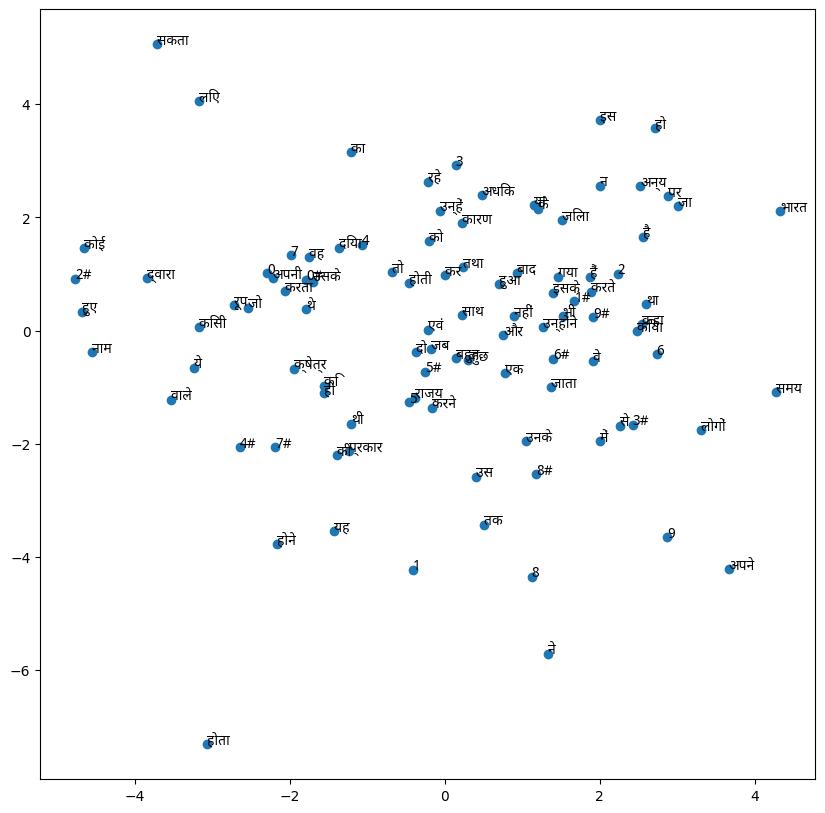

In [58]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.figure(figsize=(10, 10))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(word_int["Word"].iloc[:100]):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontproperties=font_prop)

plt.show()